## APXML final project for the starting with pytorch course

I am doing this project from scratch as the first project after following a basic course on PyTorch fundamentals.

In this project, we train a model to recognize whether a news article is fake or real.

We start simple: load, merge, encode, train a small MLP. Then we look at the scores, notice that source names (Reuters, BBC, ...) leak the label, clean the text, and train again with dropout and batch norm.


The data comes from Kaggle: [Fake and Real News Dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset/data).

These are text files, so we pretreat them before training.


In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

fakenews = pd.read_csv("data/Fake.csv")
truenews = pd.read_csv("data/True.csv")

print("Fake news shape:", fakenews.shape)
print("True news shape:", truenews.shape)
print("Columns:", list(fakenews.columns))
print()
print("One fake title:")
print(fakenews.iloc[1, 0])
print()
print("One true title:")
print(truenews.iloc[1, 0])


Fake news shape: (23481, 4)
True news shape: (21417, 4)
Columns: ['title', 'text', 'subject', 'date']

One fake title:
 Drunk Bragging Trump Staffer Started Russian Collusion Investigation

One true title:
U.S. military to accept transgender recruits on Monday: Pentagon


The files were read successfully. Each row has `title`, `text`, `subject` and `date`. We mainly use `text`.


We merge both tables and add a `label` column: fake = 0, real = 1.

Then we shuffle, otherwise the model could just learn the file order (all fake, then all real).


In [2]:
fakenews["label"] = 0
truenews["label"] = 1

df = pd.concat([fakenews, truenews], ignore_index=True)
df["text"] = df["text"].fillna("")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df["label"].value_counts())
print()
print(df[["title", "label"]].head())


label
0    23481
1    21417
Name: count, dtype: int64

                                               title  label
0  Ben Stein Calls Out 9th Circuit Court: Committ...      0
1  Trump drops Steve Bannon from National Securit...      1
2  Puerto Rico expects U.S. to lift Jones Act shi...      1
3   OOPS: Trump Just Accidentally Confirmed He Le...      0
4  Donald Trump heads for Scotland to reopen a go...      1


Train / val / test. `stratify` keeps the same fake/real ratio in each split.


In [3]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)
df_train, df_val = train_test_split(
    df_train, test_size=0.1, random_state=42, stratify=df_train["label"]
)

print("Train:", df_train.shape, "Val:", df_val.shape, "Test:", df_test.shape)


Train: (32326, 5) Val: (3592, 5) Test: (8980, 5)


TF-IDF maps text to numbers. We `fit` only on train so val and test stay unseen.

`max_features=5000` keeps the vectors at a reasonable size.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(df_train["text"]).toarray()
X_val = vectorizer.transform(df_val["text"]).toarray()
X_test = vectorizer.transform(df_test["text"]).toarray()

y_train = df_train["label"].to_numpy()
y_val = df_val["label"].to_numpy()
y_test = df_test["label"].to_numpy()

print("X_train shape:", X_train.shape)


X_train shape: (32326, 5000)


PyTorch Dataset: one article at a time. Labels are float because `BCEWithLogitsLoss` wants floats.


In [5]:
import torch
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(42)


class NewsDataset(Dataset):
    def __init__(self, X, y):
        assert len(X) == len(y)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32):
    train_loader = DataLoader(NewsDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(NewsDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(NewsDataset(X_test, y_test), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = make_loaders(X_train, y_train, X_val, y_val, X_test, y_test)
print("One batch:", tuple(next(iter(train_loader))[0].shape))


One batch: (32, 5000)


First model: a plain MLP.

`5000 -> 256 -> ReLU -> 32 -> ReLU -> 1 logit`

We turn the logit into a probability with `sigmoid` only when we predict.


In [6]:
import torch.nn as nn


class FirstModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(5000, 256)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(256, 32)
        self.layer3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        x = self.layer3(x)
        return x


In [7]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate_model(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device).unsqueeze(1)
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


class EarlyStopping:
    def __init__(self, patience=5, path="best_model.pth"):
        self.patience = patience
        self.path = path
        self.counter = 0
        self.best_loss = float("inf")
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def run_training(model, train_loader, val_loader, criterion, optimizer, device, path, num_epochs=25, patience=5):
    stopper = EarlyStopping(patience=patience, path=path)
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(
            f"Epoch {epoch + 1:02d}/{num_epochs}  "
            f"train {train_loss:.4f} ({train_acc:.3f})  "
            f"val {val_loss:.4f} ({val_acc:.3f})"
        )
        stopper.step(val_loss, model)
        if stopper.should_stop:
            print("Early stopping after epoch", epoch + 1)
            break

    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.eval()
    print("Best val loss:", round(stopper.best_loss, 4))
    return train_losses, train_accuracies, val_losses, val_accuracies


We train and stop when val loss stops improving. The best weights are written to disk quietly, then reloaded at the end.


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = FirstModel().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, train_accuracies, val_losses, val_accuracies = run_training(
    model, train_loader, val_loader, criterion, optimizer, device, path="model_raw.pth"
)


Device: cpu
Epoch 01/25  train 0.0806 (0.976)  val 0.0353 (0.990)
Epoch 02/25  train 0.0110 (0.997)  val 0.0379 (0.989)
Epoch 03/25  train 0.0034 (0.999)  val 0.0447 (0.990)
Epoch 04/25  train 0.0015 (1.000)  val 0.0553 (0.990)
Epoch 05/25  train 0.0015 (1.000)  val 0.0619 (0.989)
Epoch 06/25  train 0.0051 (0.998)  val 0.0480 (0.989)
Early stopping after epoch 6
Best val loss: 0.0353


Only 6 epochs and the model is already performing better

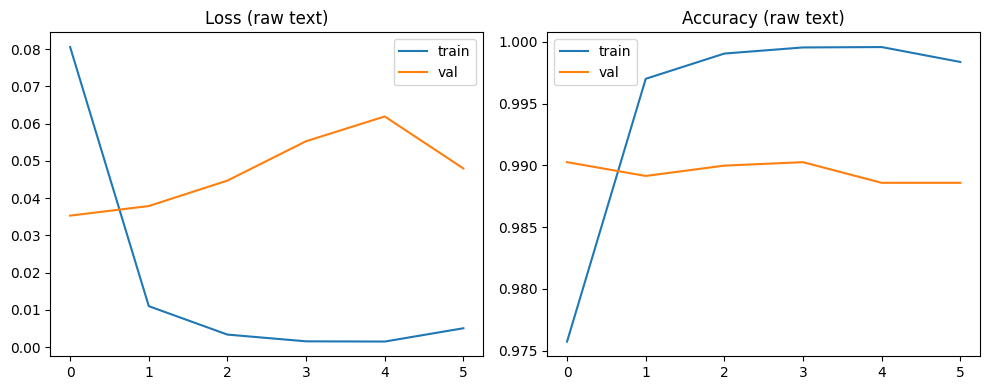

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_title("Loss (raw text)")
axes[0].legend()
axes[1].plot(train_accuracies, label="train")
axes[1].plot(val_accuracies, label="val")
axes[1].set_title("Accuracy (raw text)")
axes[1].legend()
plt.tight_layout()
plt.show()


Test set, plus precision / recall / F1. Accuracy alone is not enough if one class is easier.


In [10]:
@torch.no_grad()
def collect_preds(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for X, y in loader:
        X = X.to(device)
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy().ravel())
        all_labels.extend(y.numpy().ravel())
        all_probs.extend(probs.cpu().numpy().ravel())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


raw_test_loss, raw_test_acc = evaluate_model(model, test_loader, criterion, device)
y_true, y_pred, y_prob = collect_preds(model, test_loader, device)
print(f"Test loss: {raw_test_loss:.4f}")
print(f"Test accuracy: {raw_test_acc:.4f}")
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))


Test loss: 0.0266
Test accuracy: 0.9900
Precision: 0.9872211895910781
Recall: 0.9918300653594772
F1: 0.9895202608290639


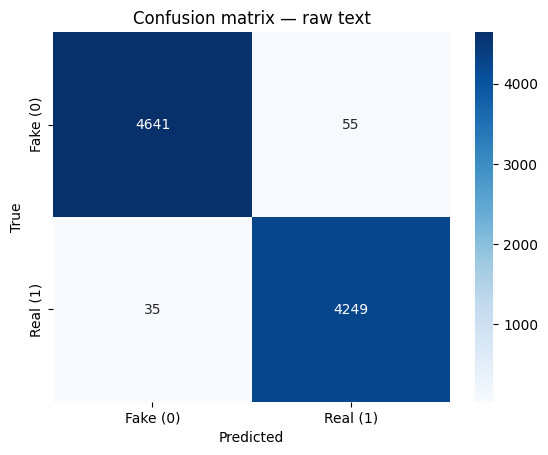

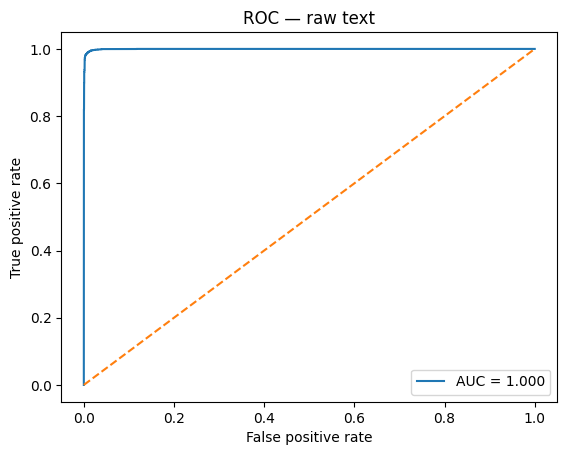

In [11]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Fake (0)", "Real (1)"],
    yticklabels=["Fake (0)", "Real (1)"],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — raw text")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC — raw text")
plt.legend()
plt.show()


Same TF-IDF, but LogReg and a linear SVM. If they match the MLP, the network is not doing extra work.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train, y_train)
print("LogReg accuracy:", accuracy_score(y_test, logreg.predict(X_test)))

svm = LinearSVC()
svm.fit(X_train, y_train)
print("SVM accuracy:", accuracy_score(y_test, svm.predict(X_test)))
print("MLP accuracy:", round(raw_test_acc, 4))


LogReg accuracy: 0.9874164810690423
SVM accuracy: 0.9943207126948775
MLP accuracy: 0.99


The scores look too good. Let's try a short sentence, then the same sentence with a source name.

If adding "Reuters" or "BBC" flips the prediction, the model is using the agency, not the content.


In [13]:
def predict_text(model, vectorizer, text, device, cleaner=None):
    model.eval()
    if cleaner is not None:
        text = cleaner(text)
    X = vectorizer.transform([text]).toarray()
    X = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        proba = torch.sigmoid(model(X)).item()
    return proba, int(proba > 0.5)


base = "Donald Trump said today that the economy is getting stronger."
for text in (base, base + " Reuters", base + " BBC"):
    proba, pred = predict_text(model, vectorizer, text, device)
    tag = "REAL" if pred == 1 else "FAKE"
    print(f"[{tag}] P(real)={proba:.3f}  |  {text}")


[FAKE] P(real)=0.283  |  Donald Trump said today that the economy is getting stronger.
[REAL] P(real)=0.993  |  Donald Trump said today that the economy is getting stronger. Reuters
[FAKE] P(real)=0.144  |  Donald Trump said today that the economy is getting stronger. BBC


As we can see, a source name is often enough to push the model toward "real". Let's measure how often those words appear, then remove them so the pattern has to be learned differently.

Punctuation and digits do not tell us if a story is fake or real, so we drop them too. Same for URLs.


In [14]:
for word in ("reuters", "bbc", "cnn", "associated press"):
    fake_r = df.loc[df["label"] == 0, "text"].str.contains(word, case=False).mean()
    true_r = df.loc[df["label"] == 1, "text"].str.contains(word, case=False).mean()
    print(f"{word:20s}  fake={fake_r:.3f}  real={true_r:.3f}")

print()
print("Start of a real article:")
print(repr(truenews["text"].iloc[0][:140]))
print()
print("Start of a fake article:") 
print(repr(fakenews["text"].iloc[0][:140]))


reuters               fake=0.014  real=0.998
bbc                   fake=0.008  real=0.007
cnn                   fake=0.091  real=0.029
associated press      fake=0.012  real=0.004

Start of a real article:
'WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the '

Start of a fake article:
'Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, hat'


In [15]:
import re
import string

SOURCES = r"\b(reuters|associated press|ap|cnn|bbc|fox news|msnbc|nbc|nytimes|new york times|washington post|the guardian|al jazeera|bloomberg|forbes|usa today|daily mail)\b"


def clean_text(text):
    text = str(text)
    # "WASHINGTON (Reuters) - ..."
    text = re.sub(r"^.*?\([^)]*\)\s*-\s*", "", text, count=1)
    text = re.sub(SOURCES, " ", text, flags=re.I)
    text = re.sub(r"http\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation + "“”‘’"))
    text = re.sub(r"\d+", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


df_train = df_train.copy()
df_val = df_val.copy()
df_test = df_test.copy()
df_train["text"] = df_train["text"].map(clean_text)
df_val["text"] = df_val["text"].map(clean_text)
df_test["text"] = df_test["text"].map(clean_text)

print("After cleaning:")
print(repr(df_train["text"].iloc[0][:180]))
print("Unique words in that article:", len(set(df_train["text"].iloc[0].split())))


After cleaning:
'the nfl was able to take a stand when it comes to the cowboys attempt to honoring slain police officers in their hometown but when an nfl player posts an isis type execution of a p'
Unique words in that article: 325


We rebuild TF-IDF on the cleaned train set, then new loaders. The old dense matrices are dropped to free RAM.


In [16]:
del X_train, X_val, X_test

vectorizer_clean = TfidfVectorizer(max_features=5000)
X_train = vectorizer_clean.fit_transform(df_train["text"]).toarray()
X_val = vectorizer_clean.transform(df_val["text"]).toarray()
X_test = vectorizer_clean.transform(df_test["text"]).toarray()

train_loader, val_loader, test_loader = make_loaders(X_train, y_train, X_val, y_val, X_test, y_test)
print("X_train shape:", X_train.shape)
print("reuters" in vectorizer_clean.vocabulary_)


X_train shape: (32326, 5000)
False


Now a second training, with batch norm and dropout so the net regularizes a bit.

Order we use: linear -> batch norm -> ReLU -> dropout.


In [17]:
class SecondModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(5000, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.drop1 = nn.Dropout(0.3)
        self.layer2 = nn.Linear(256, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.drop2 = nn.Dropout(0.3)
        self.layer3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.drop1(torch.relu(self.bn1(self.layer1(x))))
        x = self.drop2(torch.relu(self.bn2(self.layer2(x))))
        return self.layer3(x)


model_clean = SecondModel().to(device)
optimizer_clean = torch.optim.Adam(model_clean.parameters(), lr=1e-3)

train_losses, train_accuracies, val_losses, val_accuracies = run_training(
    model_clean,
    train_loader,
    val_loader,
    criterion,
    optimizer_clean,
    device,
    path="best_model.pth",
)


Epoch 01/25  train 0.0972 (0.971)  val 0.0403 (0.986)
Epoch 02/25  train 0.0336 (0.989)  val 0.0402 (0.988)
Epoch 03/25  train 0.0257 (0.992)  val 0.0385 (0.989)
Epoch 04/25  train 0.0182 (0.994)  val 0.0389 (0.988)
Epoch 05/25  train 0.0141 (0.995)  val 0.0349 (0.991)
Epoch 06/25  train 0.0097 (0.997)  val 0.0429 (0.989)
Epoch 07/25  train 0.0118 (0.996)  val 0.0469 (0.989)
Epoch 08/25  train 0.0099 (0.997)  val 0.0402 (0.990)
Epoch 09/25  train 0.0088 (0.997)  val 0.0405 (0.991)
Epoch 10/25  train 0.0067 (0.998)  val 0.0465 (0.990)
Early stopping after epoch 10
Best val loss: 0.0349


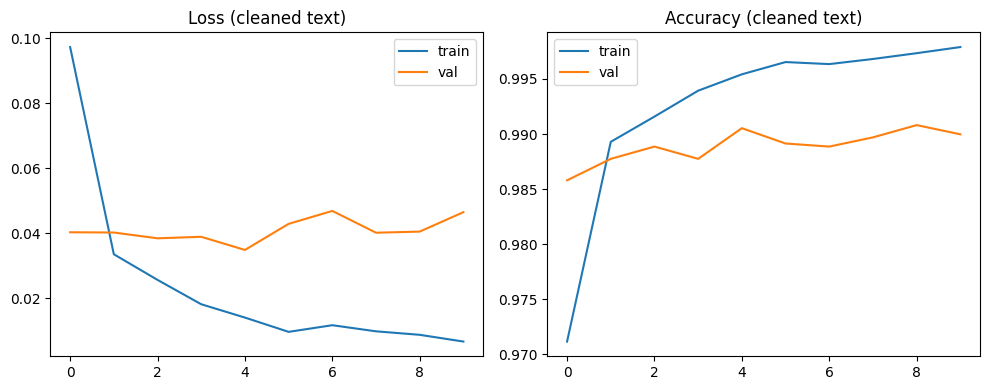

Test loss: 0.0375
Test accuracy: 0.9888
Precision: 0.9876428071811612
Recall: 0.988795518207283
F1: 0.9882188265484662

MLP on raw text:     0.99
MLP on cleaned text: 0.9888
LogReg on cleaned text: 0.9822939866369711


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_title("Loss (cleaned text)")
axes[0].legend()
axes[1].plot(train_accuracies, label="train")
axes[1].plot(val_accuracies, label="val")
axes[1].set_title("Accuracy (cleaned text)")
axes[1].legend()
plt.tight_layout()
plt.show()

clean_test_loss, clean_test_acc = evaluate_model(model_clean, test_loader, criterion, device)
y_true, y_pred, y_prob = collect_preds(model_clean, test_loader, device)
print(f"Test loss: {clean_test_loss:.4f}")
print(f"Test accuracy: {clean_test_acc:.4f}")
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))
print()
print("MLP on raw text:    ", round(raw_test_acc, 4))
print("MLP on cleaned text:", round(clean_test_acc, 4))

logreg_c = LogisticRegression(max_iter=500)
logreg_c.fit(X_train, y_train)
print("LogReg on cleaned text:", accuracy_score(y_test, logreg_c.predict(X_test)))


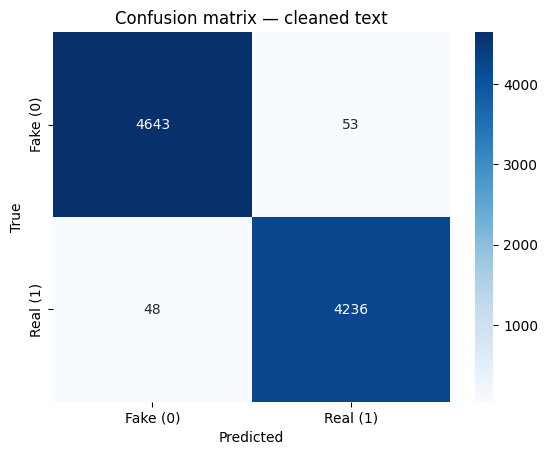

In [19]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Fake (0)", "Real (1)"],
    yticklabels=["Fake (0)", "Real (1)"],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — cleaned text")
plt.show()


Inference on the cleaned model. We run the same `clean_text` before TF-IDF, otherwise the vectorizer would see words it never fitted on.


In [20]:
model_clean.load_state_dict(torch.load("best_model.pth", map_location=device, weights_only=True))
model_clean.eval()

examples = [
    "Donald Trump said today that the economy is getting stronger.",
    "Donald Trump said today that the economy is getting stronger. Reuters",
    "WASHINGTON (Reuters) - The Senate passed a spending bill on Thursday.",
    "You will not believe what this celebrity just did. Click here before they delete it.",
]

for text in examples:
    proba, pred = predict_text(model_clean, vectorizer_clean, text, device, cleaner=clean_text)
    tag = "REAL" if pred == 1 else "FAKE"
    print(f"[{tag}] P(real)={proba:.3f}")
    print(" ", text)
    print()


[FAKE] P(real)=0.002
  Donald Trump said today that the economy is getting stronger.

[FAKE] P(real)=0.002
  Donald Trump said today that the economy is getting stronger. Reuters

[REAL] P(real)=1.000
  WASHINGTON (Reuters) - The Senate passed a spending bill on Thursday.

[FAKE] P(real)=0.000
  You will not believe what this celebrity just did. Click here before they delete it.



### Conclusion

The hard part of this project was not the network. It was the data.

Before any training, we had to turn raw news text into something a model can use: labels, a shuffle, a train/val/test split, then TF-IDF. After the first MLP, the test accuracy was about **0.99**. That looked too good. A short sentence stayed fake, but the same sentence plus the word **Reuters** became real (probability 0.28 → 0.99). Almost every real article in this Kaggle set contains that word (about 99.8%), almost none of the fake ones do. The model was using the news agency, not the story.

So we cleaned the text: source names (Reuters, BBC, CNN, AP, …), the `CITY (Reuters) -` header, URLs, punctuation and digits. We trained again, this time with batch norm and dropout. After cleaning, adding “Reuters” no longer changes the prediction. The test accuracy stayed high (**0.9888**, LogReg **0.982**). The shortcut is gone, but real and fake articles still *sound* different, so the task is still easy on this dataset.

On the optimizer: we first tried SGD. The loss was stable, but accuracy and the other scores were poor. Adam learned much faster, so we kept it.

For this problem a simple MLP on TF-IDF is enough. A bigger model would not fix the real limit, which is the data. If we had more compute, we would rather collect harder articles (without agency prefixes) than stack more layers. An RNN could read the text in order, but with bag-of-words already this strong, we do not expect a large gain here. A next step we find more interesting is to use the same corpus to train a small text model (next-word / generation), or to add the title next to the body.

The weights we keep are `best_model.pth` (cleaned text, `SecondModel`). Inference must go through `clean_text` and `vectorizer_clean`, the same pipeline we fitted on train.
 